In [ ]:
!pip install matplotlib seaborn sklearn 


In [3]:
# Studen Score Analyzer & Grade Predictor
# Predicts student math scores and flags at-risk students - for teachers , who needs early warning signals !

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# download the Student Performance Dataset from Kaggle : https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

# load/read it with pandas 

Student_data = pd.read_csv("StudentsPerformance.csv")



In [5]:
# print the shape (rows X columns)!

Student_data.shape 


(1000, 8)

In [6]:
# print columns names

Student_data.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [7]:
# print the first few rows 

Student_data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
# Explore data types 

Student_data.dtypes 


gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [9]:
# check for missing values 

Student_data[Student_data.isnull().any(axis = "columns")]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score


In [10]:
# using loc and iloc to slice specific rows and columns (select 3 score columns)

Student_data.iloc[:,-3:]

Student_data.loc[:,["math score","reading score","writing score"]]

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75
...,...,...,...
995,88,99,95
996,62,55,55
997,59,71,65
998,68,78,77


In [11]:
# use apply() with lambda to create a new column "total_score" by summing the three subject scores

total_score = Student_data.loc[:,["math score","reading score","writing score"]].apply(lambda d : d.sum() , axis = "columns")
Student_data["total_score"] = total_score

In [12]:
# use map() to create a "grade_label" column(A/B/C/F) based on total score ranges 

def grade(score):
    if 27 < score < 175:
        grade="F"
    elif 205 > score >= 175:
        grade="C"
    elif 233 > score >= 205:
        grade="B"
    else:
        grade="A"
    return grade

grade_label = total_score.map(grade)
grade_label
Student_data["grade_label"] = grade_label


In [13]:
# use groupby() to find the average score by parental education and lunch type. use sort_values() to rank them

Student_data.groupby(["parental level of education","lunch"]).total_score.mean().sort_values()

parental level of education  lunch       
some high school             free/reduced    171.672131
high school                  free/reduced    172.128571
some college                 free/reduced    188.911392
associate's degree           free/reduced    196.285714
high school                  standard        198.825397
bachelor's degree            free/reduced    201.159091
master's degree              free/reduced    201.333333
some high school             standard        207.550847
some college                 standard        214.306122
associate's degree           standard        215.303448
bachelor's degree            standard        224.459459
master's degree              standard        234.142857
Name: total_score, dtype: float64

In [14]:
# rename at least 2 columns to cleaner names

Student_data.rename(columns = {"total_score":"total score","grade_label":"grade label"},inplace=True)

In [15]:
# concat the cleaned DataFrame with a small hand-made DataFrame of 3 fake students you create from a dictionary

Fake_data = pd.DataFrame({"gender":['female','male','female'],"race/ethnicity":['group B','group A','group C'],"parental level of education":['bachelor\'s degree','some college','master\'s degree'],"lunch":['standard','standard','standard'],"test preparation course":['none','none','none'],"math score":[72,69,90],"reading score":[72,90,95],"writing score":[74,88,93],"total score":[218,247,278],"grade label":['B','A','A']})

Student_data = pd.concat([Student_data, Fake_data], ignore_index=True)
Student_data


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,grade label
0,female,group B,bachelor's degree,standard,none,72,72,74,218,B
1,female,group C,some college,standard,completed,69,90,88,247,A
2,female,group B,master's degree,standard,none,90,95,93,278,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,F
4,male,group C,some college,standard,none,76,78,75,229,B
...,...,...,...,...,...,...,...,...,...,...
998,female,group D,some college,standard,completed,68,78,77,223,B
999,female,group D,some college,free/reduced,none,77,86,86,249,A
1000,female,group B,bachelor's degree,standard,none,72,72,74,218,B
1001,male,group A,some college,standard,none,69,90,88,247,A


Text(0, 0.5, 'Average score')

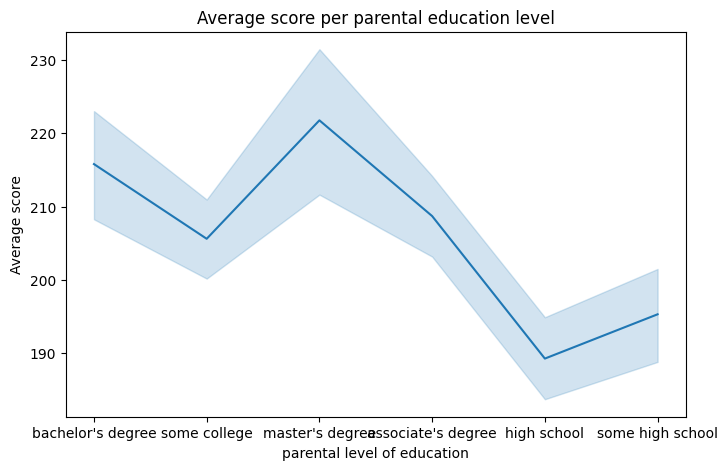

In [16]:
# Visualize 

# line chart of average score per parental education level

plt.figure(figsize=(8,5))
plt.title("Average score per parental education level")
sns.lineplot(x="parental level of education",y="total score",data=Student_data)
plt.ylabel("Average score")

<Axes: title={'center': 'Average score by lunch'}, xlabel='lunch', ylabel='total score'>

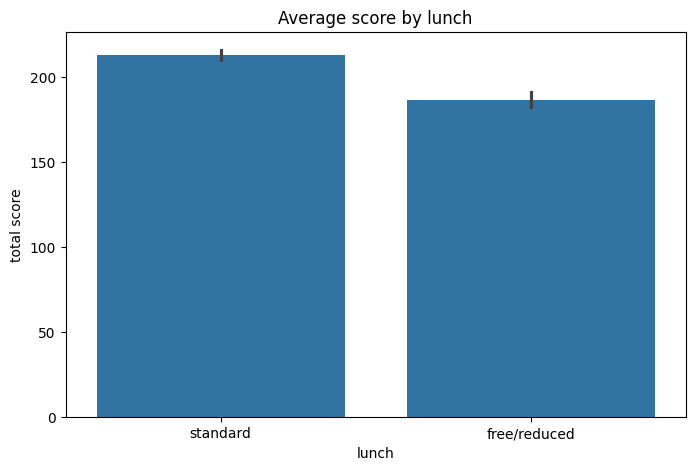

In [17]:
# bar chart of average score by lunch

plt.figure(figsize=(8,5))
plt.title("Average score by lunch")
sns.barplot(x = Student_data['lunch'] , y = Student_data['total score'])

<Axes: title={'center': 'heatmap of feature correlation'}>

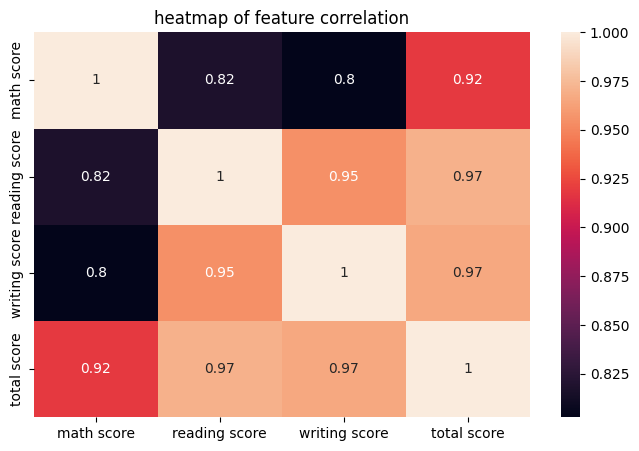

In [18]:
# heatmap of feature correlation

plt.figure(figsize=(8,5))
plt.title("heatmap of feature correlation")

sns.heatmap(data = Student_data.corr(numeric_only=True) , annot=True)

Text(0.5, 1.0, 'Scatter plot of reading v/s writing scores colored by gender')

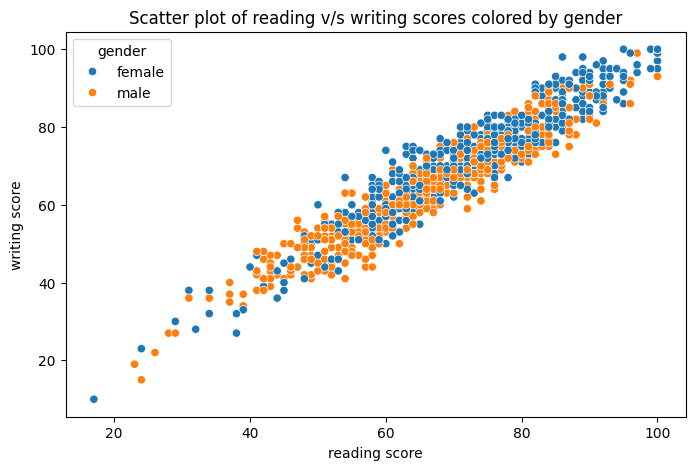

In [19]:
# scatter plot of reading v/s writing score colored by gender
plt.figure(figsize=(8,5))
sns.scatterplot(x="reading score",y="writing score",hue="gender",data = Student_data)
plt.title("Scatter plot of reading v/s writing scores colored by gender")

C:\Users\anike\AppData\Local\Temp\ipykernel_13024\1912808776.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=Student_data['total score'],shade = True)


<Axes: title={'center': 'KDE of total score distribution'}, xlabel='total score', ylabel='Density'>

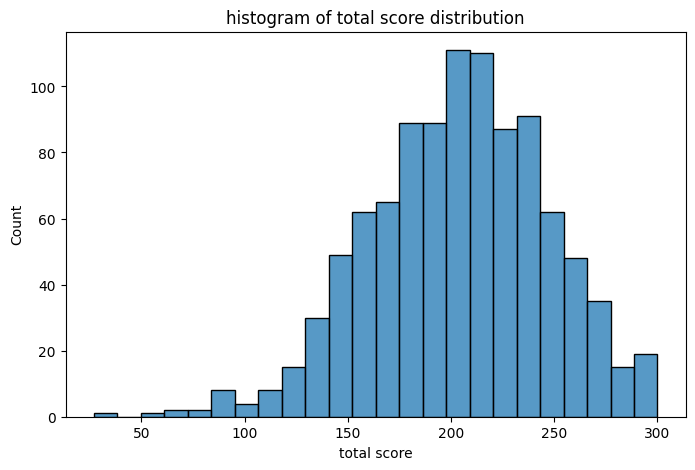

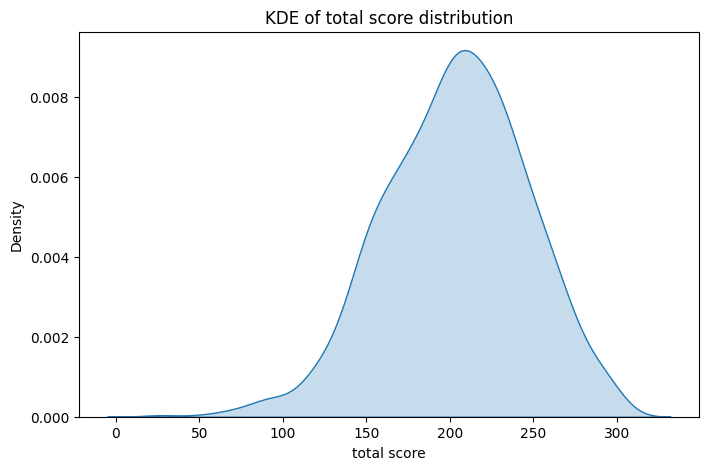

In [20]:
# histogram + KDE of total score distribution

# histogram 
plt.figure(figsize=(8,5))
plt.title("histogram of total score distribution")
sns.histplot(data=Student_data['total score'])

# Kernel density estimate
plt.figure(figsize=(8,5))
plt.title("KDE of total score distribution")
sns.kdeplot(data=Student_data['total score'],shade = True)

<Axes: title={'center': 'verification of custom size and theme'}, xlabel='lunch', ylabel='total score'>

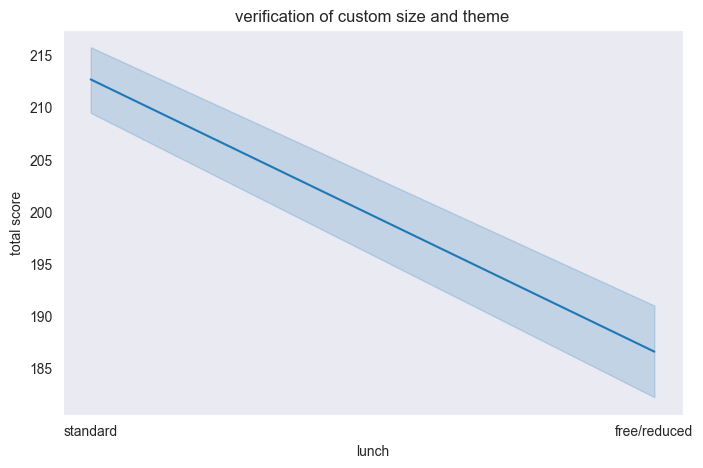

In [21]:
# apply a custom seaborn theme and set figure size
sns.set_style('dark')
plt.figure(figsize=(8,5))
plt.title("verification of custom size and theme")
sns.lineplot(x=Student_data['lunch'],y=Student_data['total score'],data = Student_data)

In [22]:
# encode categorial columns (gender,test,lunch) into numbers using a loop and dictionary mapping . use a feature list

mappings = {
    'gender': {'male':0,'female':1},
    'lunch': {'standard':1,'free/reduced':0},
    'test preparation course': {'completed':1,'none':0}
}

list_feat = ['gender', 'lunch', 'test preparation course']

for feat in list_feat:
    Student_data["new "+feat] = Student_data[feat].map(mappings[feat])

Student_data


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,grade label,new gender,new lunch,new test preparation course
0,female,group B,bachelor's degree,standard,none,72,72,74,218,B,1,1,0
1,female,group C,some college,standard,completed,69,90,88,247,A,1,1,1
2,female,group B,master's degree,standard,none,90,95,93,278,A,1,1,0
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,F,0,0,0
4,male,group C,some college,standard,none,76,78,75,229,B,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
998,female,group D,some college,standard,completed,68,78,77,223,B,1,1,1
999,female,group D,some college,free/reduced,none,77,86,86,249,A,1,0,0
1000,female,group B,bachelor's degree,standard,none,72,72,74,218,B,1,1,0
1001,male,group A,some college,standard,none,69,90,88,247,A,0,1,0


In [23]:
# split into X and y

from sklearn.model_selection import train_test_split

# prediction target
y = Student_data['math score']

# feature 
feature_list = ['reading score','writing score','new gender','new lunch','new test preparation course']
X = Student_data[feature_list]

train_X,val_X,train_y,val_y = train_test_split(X,y,random_state=1)


In [24]:
# Train a Decision tree , measure mean absolute error

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

decision_tree_model = DecisionTreeRegressor(random_state=2)
decision_tree_model.fit(train_X,train_y)
tree_pred = decision_tree_model.predict(val_X)
MAE_tree = mean_absolute_error(val_y,tree_pred)

MAE_tree


6.608233731739708

In [25]:
# Train a Random Forests , measure MAE (mean absolute error)

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(random_state=2)
random_forest_model.fit(train_X,train_y)
forest_pred = random_forest_model.predict(val_X)
MAE_forest = mean_absolute_error(val_y,forest_pred)

MAE_forest


4.8149996996142415

In [26]:
# which model wins (compare both tree and forest)

print("decision tree wins" if MAE_tree < MAE_forest else "Random Froest wins")

Random Froest wins


In [34]:
# write a python function that takes a student dict as input , puts it into a DataFrame , and returns the predicted score.
# use a docstring. Test it with 3 fake students using a for loop

def what_score(dict):
    
    """this predicts the math score of students 
       the model used is Random Forest model """
    

    data = pd.DataFrame(dict)
    feature_list = ['reading score','writing score','new gender','new lunch','new test preparation course']
    X = data[feature_list]
    score = random_forest_model.predict(X)
    return score


# testing for 3 fake studs 
Fake = {"reading score":[72,90,95],"writing score":[74,88,93],"new gender":[0,0,1],"new lunch":[1,1,0],"new test preparation course":[0,1,0]}
print(list(what_score(Fake)))



[np.float64(78.81035714285714), np.float64(80.72), np.float64(82.18)]
